<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/AI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
stocks = pd.read_csv('historical_stocks.csv')
prices = pd.read_csv('historical_stock_prices.csv')



In [10]:
# Preview data
print(stocks.head())
print(prices.head())


  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PROPERTY-CASUALTY INSURERS  
2  FINANCE/INVESTORS SERVICES  
3      OTHER SPECIALTY STORES  
4        SAVINGS INSTITUTIONS  
  ticker   open  close  adj_close    low   high   volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   1

In [11]:
# Check structure
print(stocks.info())
print(prices.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     object 
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date       object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.3+ GB
None


In [12]:

# Check missing values
print(prices.isnull().sum())
print(stocks.isnull().sum())



ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64


In [13]:
stocks["sector"].fillna("Unknown", inplace=True)
stocks["industry"].fillna("Unknown", inplace=True)


/tmp/ipykernel_56686/3343637660.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stocks["sector"].fillna("Unknown", inplace=True)
/tmp/ipykernel_56686/3343637660.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [14]:
print(prices.isnull().sum())
print(stocks.isnull().sum())



ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64
ticker      0
exchange    0
name        0
sector      0
industry    0
dtype: int64


In [15]:
# checking for duplicates
stocks.duplicated().sum()
prices.duplicated().sum()


np.int64(0)

In [16]:
import pandas as pd
prices = pd.read_csv('historical_stock_prices.csv')
stocks = pd.read_csv('historical_stocks.csv')

# We merge the 2 dataset
merged= pd.merge(prices, stocks, on='ticker', how='left')
print(merged.head())

  ticker   open  close  adj_close    low   high   volume        date exchange  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013-05-08     NYSE   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013-05-09     NYSE   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013-05-10     NYSE   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400  2013-05-13     NYSE   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100  2013-05-14     NYSE   

                              name   sector     industry  
0  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
1  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
2  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
3  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
4  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  


In [17]:
# we add decade column
merged["date"] = pd.to_datetime(merged["date"], errors='coerce')
merged["decade"] = (merged["date"].dt.year // 10) * 10
print(merged.head())


  ticker   open  close  adj_close    low   high   volume       date exchange  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900 2013-05-08     NYSE   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800 2013-05-09     NYSE   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100 2013-05-10     NYSE   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400 2013-05-13     NYSE   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100 2013-05-14     NYSE   

                              name   sector     industry  decade  
0  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  
1  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  
2  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  
3  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  
4  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  


In [18]:
import pandas as pd

# Load the datasets again to ensure 'merged' is defined
stocks = pd.read_csv('historical_stocks.csv')
prices = pd.read_csv('historical_stock_prices.csv')

# Merge the two datasets
merged = pd.merge(prices, stocks, on='ticker', how='left')

# Convert 'date' to datetime and add 'decade' column
merged["date"] = pd.to_datetime(merged["date"], errors='coerce')
merged["decade"] = (merged["date"].dt.year // 10) * 10

# Now create the decade_dfs dictionary
decade_dfs = {
    decade: df.copy()
    for decade, df in merged.groupby('decade')
}

In [19]:
print(decade_dfs[2010].head())


  ticker   open  close  adj_close    low   high   volume       date exchange  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900 2013-05-08     NYSE   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800 2013-05-09     NYSE   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100 2013-05-10     NYSE   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400 2013-05-13     NYSE   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100 2013-05-14     NYSE   

                              name   sector     industry  decade  
0  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  
1  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  
2  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  
3  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  
4  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE    2010  


In [20]:
# we create statiscal values
cols = ['open', 'high', 'low', 'close', 'volume']
summary_stats = {}

for decade, df in decade_dfs.items():
    summary_stats[decade] = df[cols].agg(['mean', 'median', 'std'])
    print(f"Summary statistics for {decade}:")
    print(summary_stats[decade])
    print("\n")


Summary statistics for 1970:
             open       high        low      close        volume
mean    12.491493  12.640192  12.366931  12.491549  7.248936e+05
median   2.791667   2.840909   2.765625   2.791667  1.872000e+05
std     46.981142  47.481931  46.513085  46.985360  1.377366e+06


Summary statistics for 1980:
              open        high         low       close        volume
mean     16.814261   17.095074   16.561523   16.824845  8.375234e+05
median    5.000000    5.083333    4.958333    5.000000  6.460000e+04
std     573.048093  582.814179  562.257404  575.029287  4.510088e+06


Summary statistics for 1990:
               open         high          low        close        volume
mean      45.291459    46.871896    43.814977    45.303495  8.635272e+05
median    10.583831    10.750000    10.437500    10.593750  6.220000e+04
std     1391.110191  1464.629619  1329.334616  1391.576526  5.834012e+06


Summary statistics for 2000:
               open         high          low     

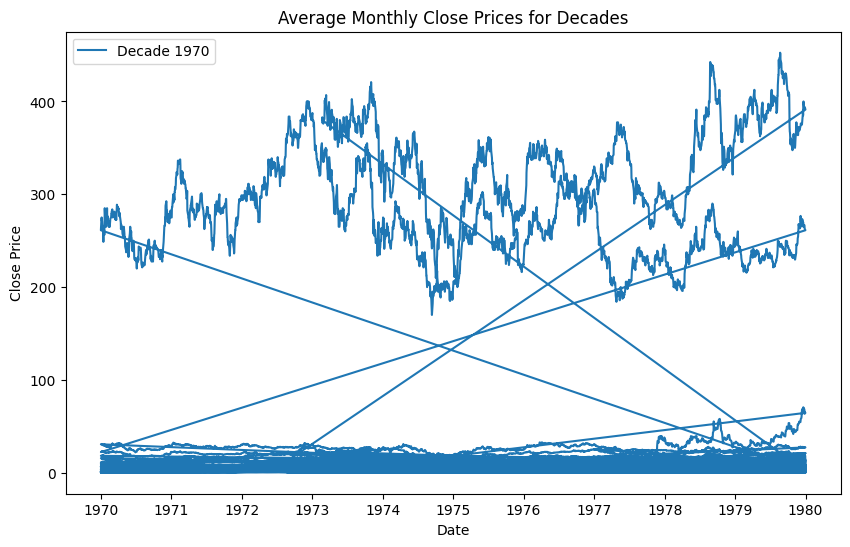

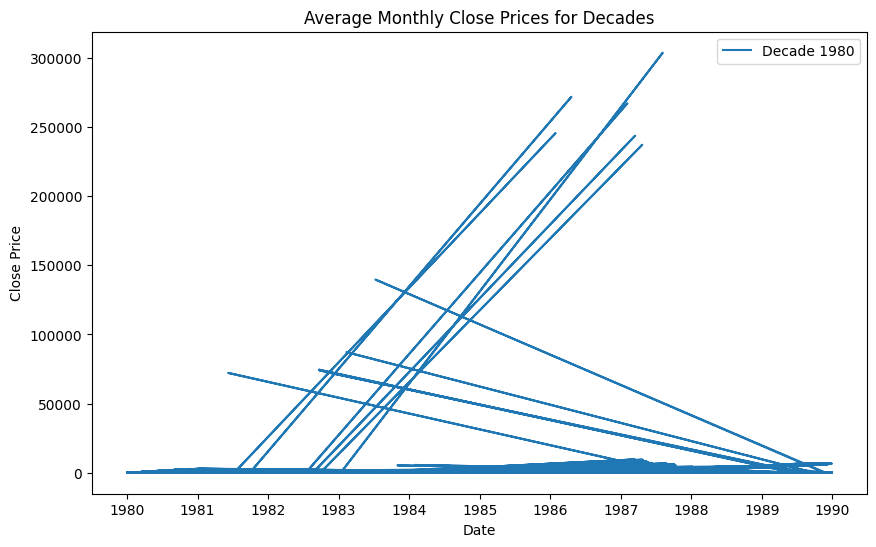

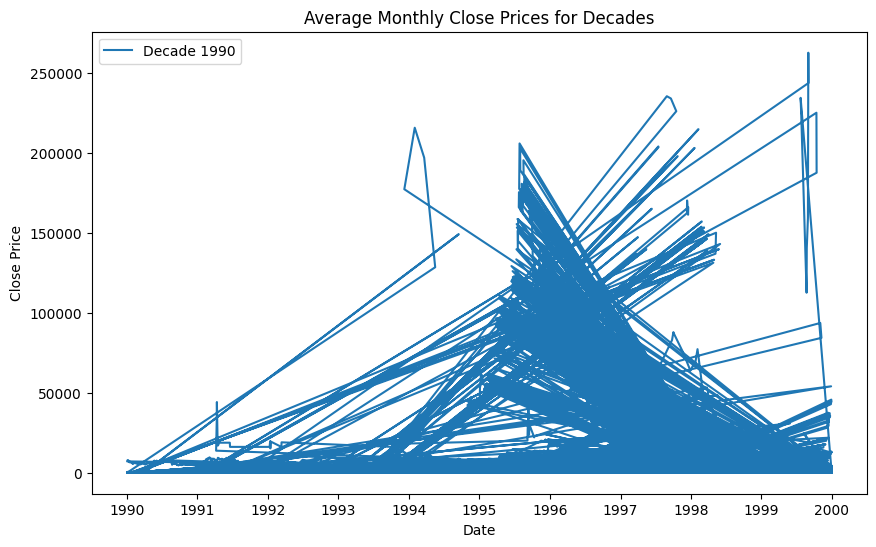

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


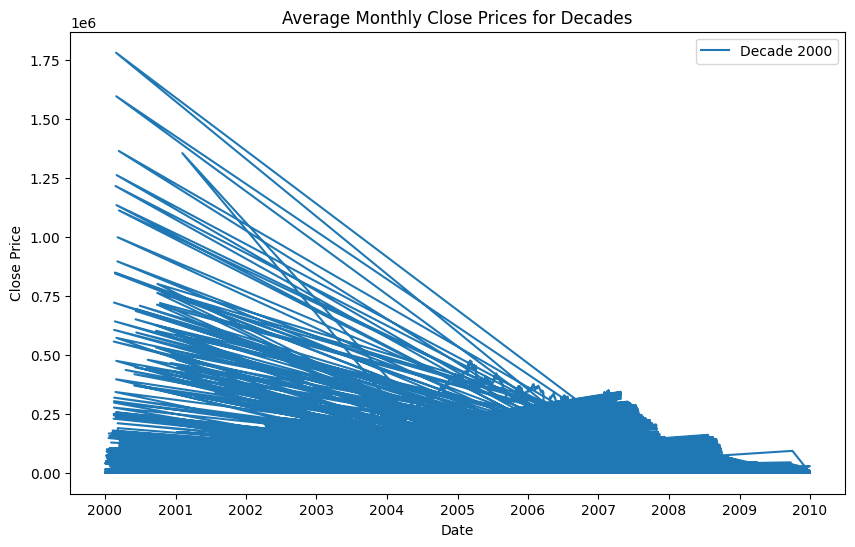

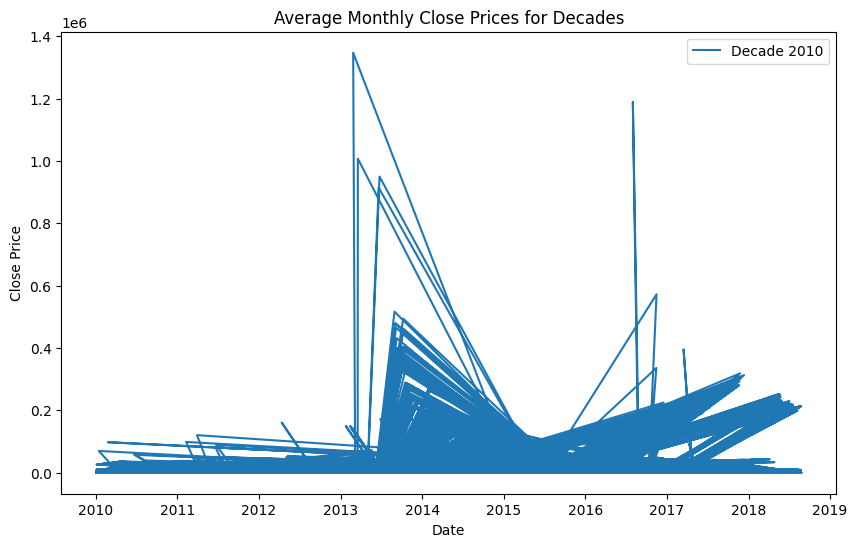

In [24]:
# Time series plots for average monthly Close prices.
import matplotlib.pyplot as plt
for decade, df in decade_dfs.items():
    plt.figure(figsize=(10, 6))
    plt.plot(df['date'], df['close'], label=f'Decade {decade}')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.title(f'Average Monthly Close Prices for Decades')
    plt.legend()
    plt.show()




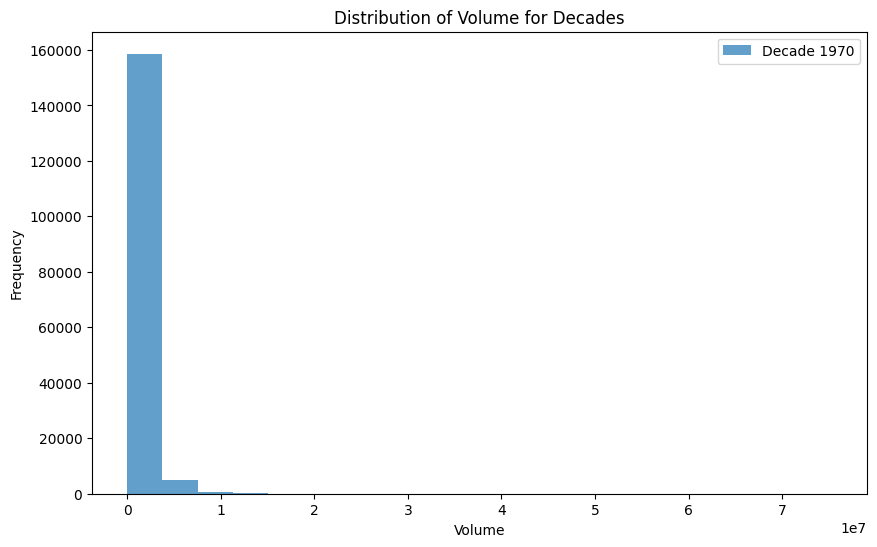

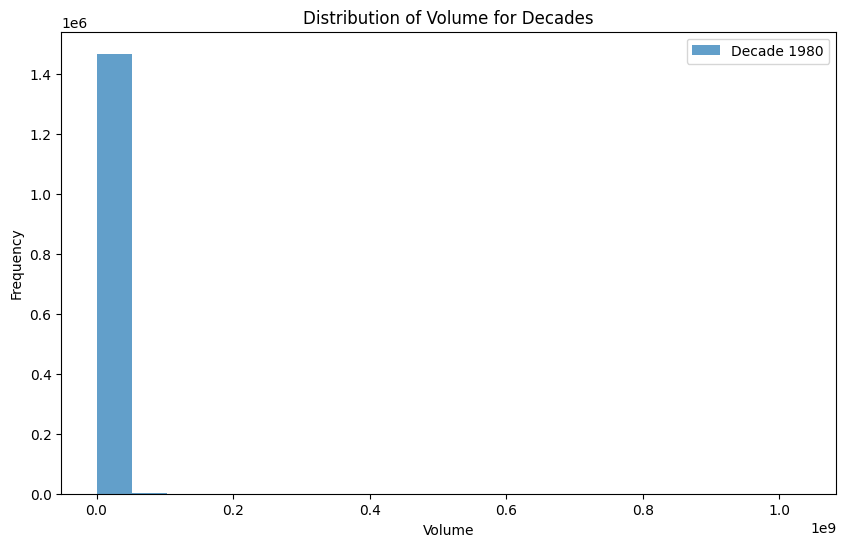

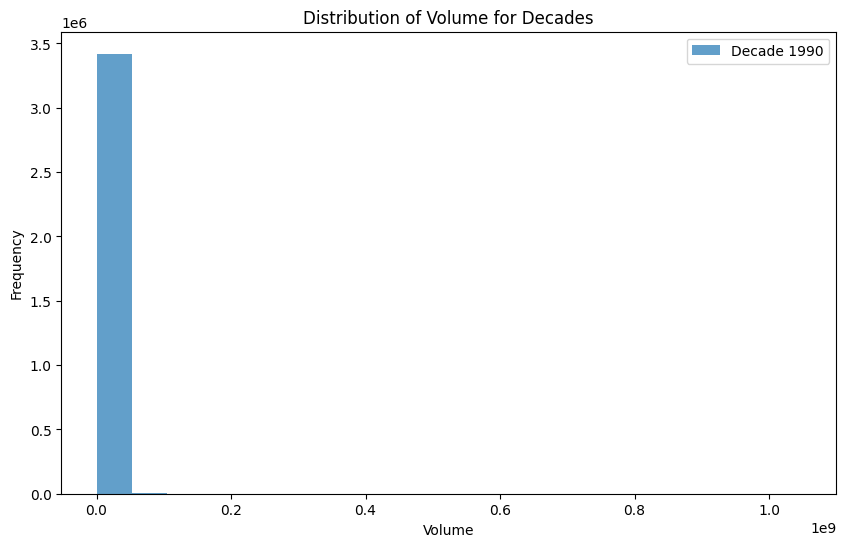

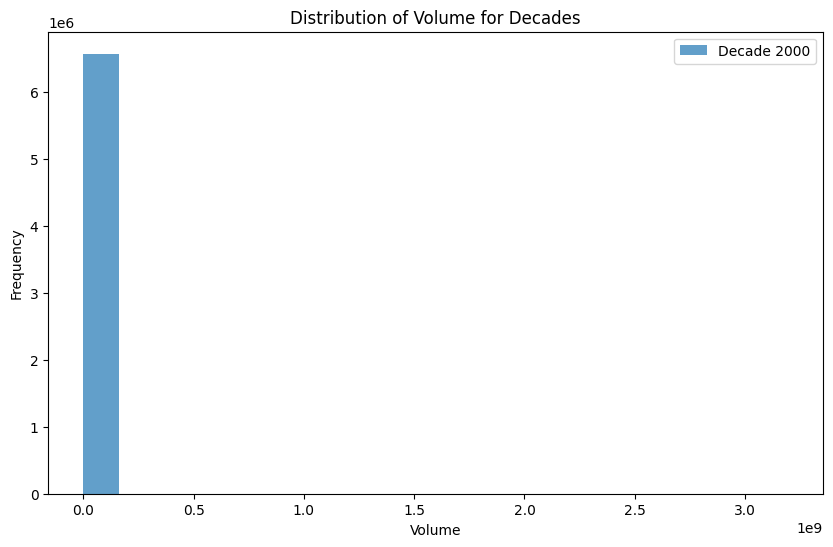

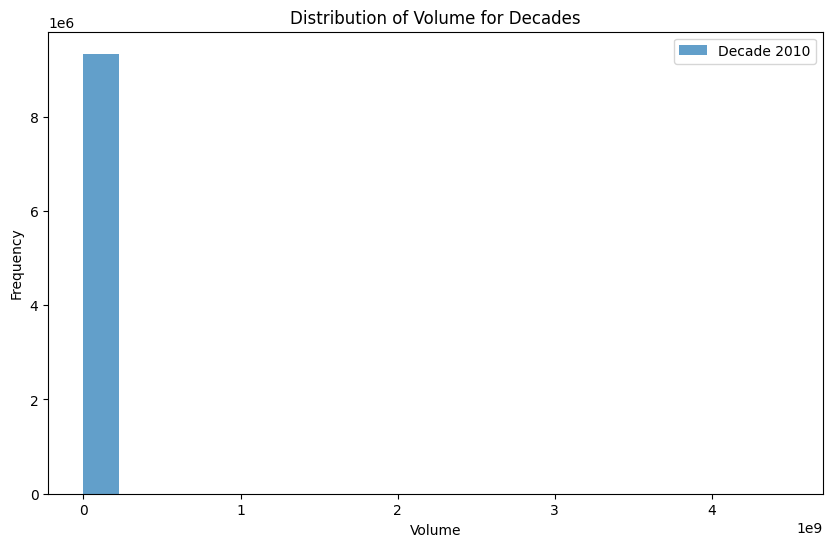

In [23]:
# histograme for volume to analyze the distribution and any shifts over the decades.
for decade, df in decade_dfs.items():
    plt.figure(figsize=(10, 6))
    plt.hist(df['volume'], bins=20, alpha=0.7, label=f'Decade {decade}')
    plt.xlabel('Volume')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Volume for Decades')
    plt.legend()
    plt.show()



/tmp/ipykernel_56686/2822757499.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['high', 'low'])


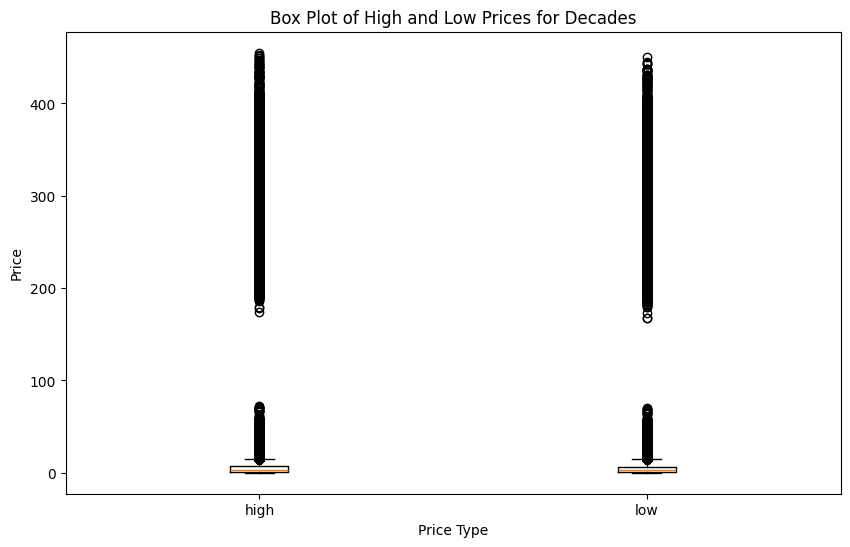

/tmp/ipykernel_56686/2822757499.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['high', 'low'])


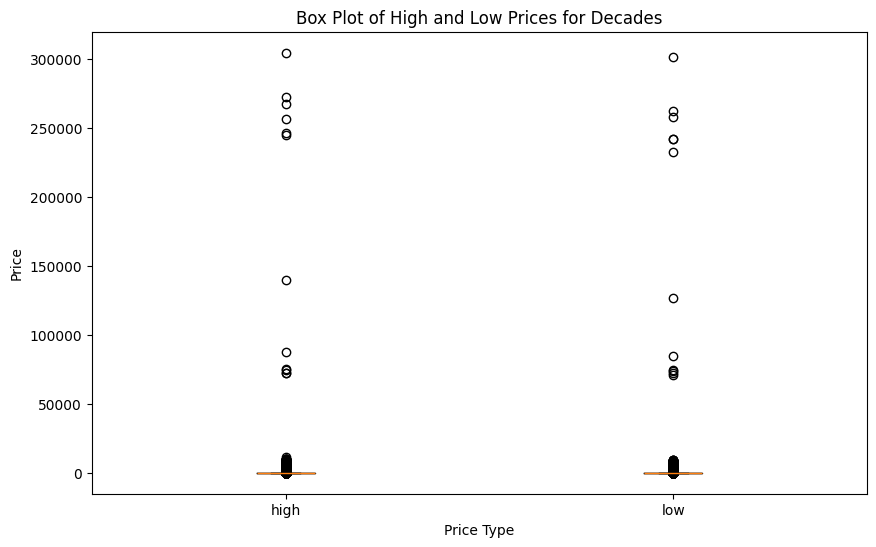

/tmp/ipykernel_56686/2822757499.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['high', 'low'])


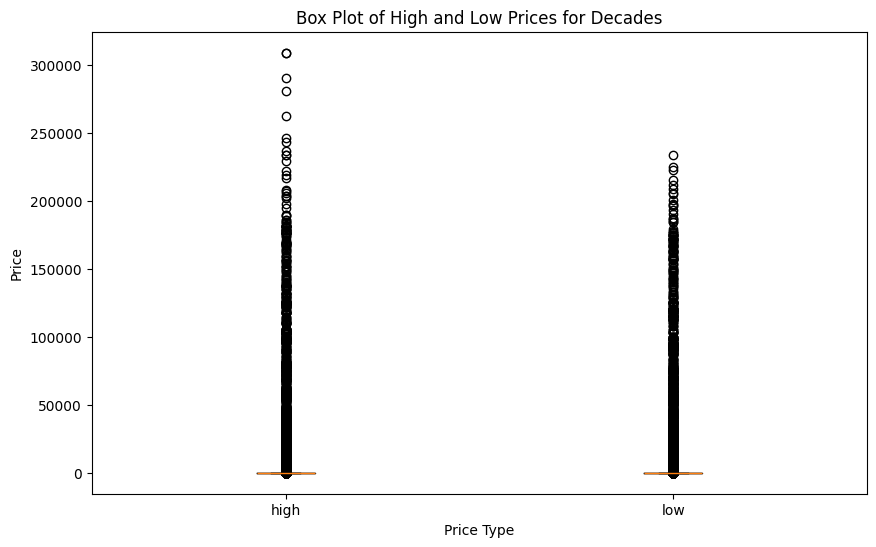

/tmp/ipykernel_56686/2822757499.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['high', 'low'])


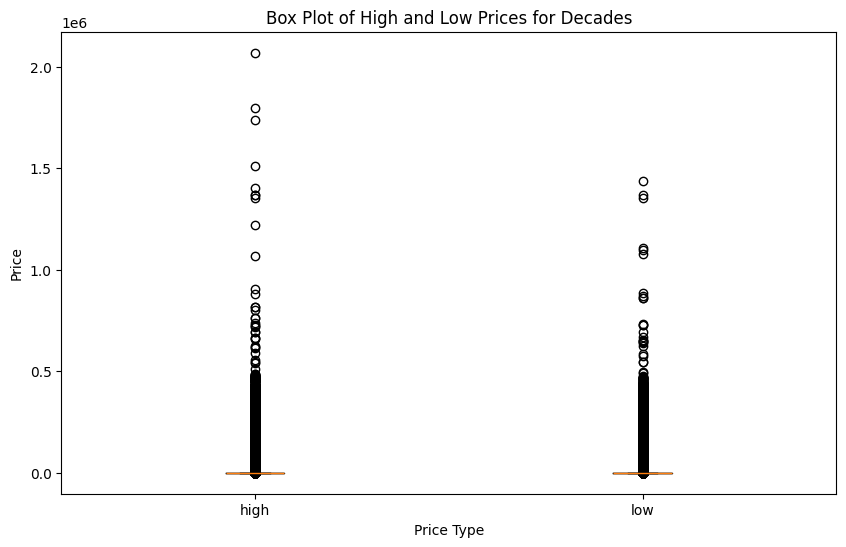

/tmp/ipykernel_56686/2822757499.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['high'], df['low']], labels=['high', 'low'])


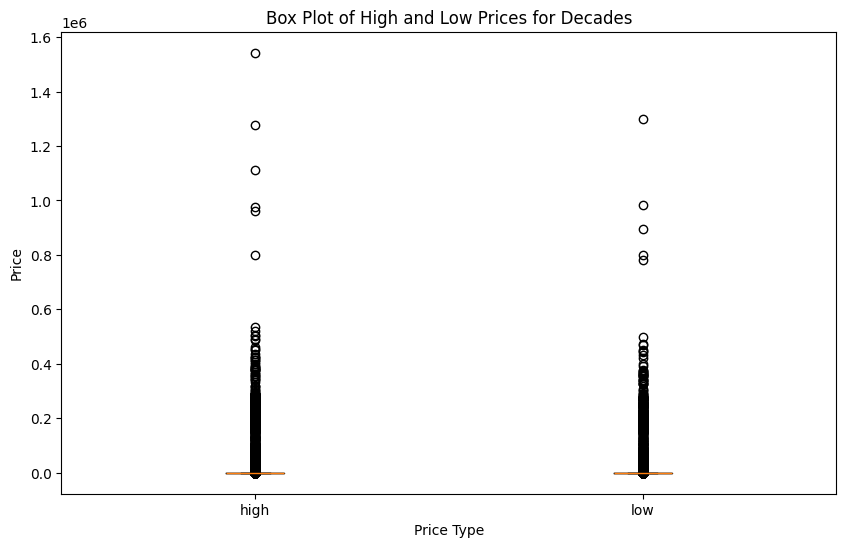

In [26]:
#Box plots for the High and Low prices to examine the range and presence of outliers.
for decade, df in decade_dfs.items():
    plt.figure(figsize=(10, 6))
    plt.boxplot([df['high'], df['low']], labels=['high', 'low'])
    plt.xlabel('Price Type')
    plt.ylabel('Price')
    plt.title(f'Box Plot of High and Low Prices for Decades')
    plt.show()
